# Spiking Neural Network (SNN) for Stock Price Prediction

This notebook implements a Spiking Neural Network using SpikingJelly to predict RELIANCE.NS stock price direction (up/down).

## Key Components:
- **Framework**: SpikingJelly (PyTorch-based)
- **Neuron Model**: LIF (Leaky Integrate-and-Fire)
- **Encoding**: Rate coding
- **Dataset**: RELIANCE.NS (Mar 2025 - Mar 2026)
- **Task**: Binary classification (next day up/down)

## 1. Import Libraries and Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from spikingjelly.activation_based import neuron, functional, layer

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report
import time
import pickle
import os

# Import data preparation module
from data_preparation import prepare_full_dataset

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create output directory
os.makedirs('outputs/snn', exist_ok=True)

%matplotlib inline
sns.set_style('whitegrid')

Using device: cuda


## 2. Load and Prepare Data

In [2]:
# Prepare dataset
print("Preparing stock dataset...\n")
data_dict = prepare_full_dataset(
    ticker="RELIANCE.NS",
    start="2025-03-04",
    end="2026-03-04",
    seq_len=20,
    train_ratio=0.8,
    save_path="./processed_data"
)

train_dataset = data_dict['train_dataset']
test_dataset = data_dict['test_dataset']
num_features = data_dict['num_features']
feature_cols = data_dict['feature_cols']

print(f"\nNumber of input features: {num_features}")
print(f"Training samples: {len(train_dataset)}")
print(f"Testing samples: {len(test_dataset)}")

Preparing stock dataset...

Downloaded 247 trading days
Added technical indicators. Total features: 27
Target created: 97/198 up days (49.0%)
Train set: 158 days
Test set: 40 days

Creating training dataset...
Created dataset: 138 sequences of shape (20, 27)
Positive class ratio: 0.500

Creating testing dataset...
Created dataset: 20 sequences of shape (20, 27)
Positive class ratio: 0.500

Data saved to ./processed_data

Number of input features: 27
Training samples: 138
Testing samples: 20


In [3]:
# Create data loaders
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 5
Test batches: 1


## 3. Define SNN Model Architecture

We use LIF (Leaky Integrate-and-Fire) neurons with rate coding:
- Input is repeated T timesteps
- Spikes accumulate over time
- Final output is averaged spike rate

In [4]:
class SNNStockPredictor(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, num_classes=2, T=25):
        super(SNNStockPredictor, self).__init__()
        self.T = T  # Time steps for rate coding
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # Flatten sequences to single vector
        self.flatten = nn.Flatten(start_dim=1)
        
        # Spiking layers with LIF neurons
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.lif1 = neuron.LIFNode(tau=2.0)
        
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.lif2 = neuron.LIFNode(tau=2.0)
        
        self.fc3 = nn.Linear(hidden_size, hidden_size // 2)
        self.lif3 = neuron.LIFNode(tau=2.0)
        
        self.fc_out = nn.Linear(hidden_size // 2, num_classes)
        
    def forward(self, x):
        # x shape: (batch, seq_len, features)
        batch_size = x.size(0)
        
        # Flatten sequence
        x = self.flatten(x)  # (batch, seq_len * features)
        
        # Reset neuron states
        functional.reset_net(self)
        
        # Rate coding: repeat input T timesteps
        spike_output = None
        
        for t in range(self.T):
            # Layer 1
            cur1 = self.fc1(x)
            spk1 = self.lif1(cur1)
            
            # Layer 2
            cur2 = self.fc2(spk1)
            spk2 = self.lif2(cur2)
            
            # Layer 3
            cur3 = self.fc3(spk2)
            spk3 = self.lif3(cur3)
            
            # Output
            out = self.fc_out(spk3)
            
            if spike_output is None:
                spike_output = out
            else:
                spike_output = spike_output + out
        
        # Average over time steps (rate coding)
        return spike_output / self.T
    
    def get_spike_counts(self, x):
        """Get spike counts for visualization"""
        batch_size = x.size(0)
        x = self.flatten(x)
        
        functional.reset_net(self)
        
        spike_counts = {'layer1': [], 'layer2': [], 'layer3': []}
        
        for t in range(self.T):
            cur1 = self.fc1(x)
            spk1 = self.lif1(cur1)
            spike_counts['layer1'].append(spk1.detach().cpu().numpy())
            
            cur2 = self.fc2(spk1)
            spk2 = self.lif2(cur2)
            spike_counts['layer2'].append(spk2.detach().cpu().numpy())
            
            cur3 = self.fc3(spk2)
            spk3 = self.lif3(cur3)
            spike_counts['layer3'].append(spk3.detach().cpu().numpy())
        
        return spike_counts

In [5]:
# Initialize model
model = SNNStockPredictor(
    input_size=num_features * 20,  # seq_len * features
    hidden_size=128,
    num_layers=2,
    num_classes=2,
    T=25
).to(device)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")

SNNStockPredictor(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=540, out_features=128, bias=True)
  (lif1): LIFNode(
    v_threshold=1.0, v_reset=0.0, detach_reset=False, step_mode=s, backend=torch, tau=2.0
    (surrogate_function): Sigmoid(alpha=4.0, spiking=True)
  )
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (lif2): LIFNode(
    v_threshold=1.0, v_reset=0.0, detach_reset=False, step_mode=s, backend=torch, tau=2.0
    (surrogate_function): Sigmoid(alpha=4.0, spiking=True)
  )
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (lif3): LIFNode(
    v_threshold=1.0, v_reset=0.0, detach_reset=False, step_mode=s, backend=torch, tau=2.0
    (surrogate_function): Sigmoid(alpha=4.0, spiking=True)
  )
  (fc_out): Linear(in_features=64, out_features=2, bias=True)
)

Total parameters: 94146


## 4. Training Setup

In [6]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

# Training parameters
num_epochs = 100
print_interval = 10

## 5. Training Loop

In [7]:
# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'test_loss': [],
    'test_acc': [],
    'test_f1': [],
    'test_precision': [],
    'test_recall': []
}

best_test_acc = 0.0
best_model_state = None

print("Starting training...\n")
start_time = time.time()

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        train_total += targets.size(0)
        train_correct += predicted.eq(targets).sum().item()
    
    train_loss /= len(train_loader)
    train_acc = 100. * train_correct / train_total
    
    # Testing phase
    model.eval()
    test_loss = 0.0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            test_loss += loss.item()
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    
    test_loss /= len(test_loader)
    test_acc = accuracy_score(all_targets, all_preds) * 100
    test_f1 = f1_score(all_targets, all_preds)
    test_precision = precision_score(all_targets, all_preds)
    test_recall = recall_score(all_targets, all_preds)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    history['test_f1'].append(test_f1)
    history['test_precision'].append(test_precision)
    history['test_recall'].append(test_recall)
    
    # Save best model
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_model_state = model.state_dict().copy()
    
    # Print progress
    if (epoch + 1) % print_interval == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"  Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")
        print(f"  Test F1: {test_f1:.4f}, Precision: {test_precision:.4f}, Recall: {test_recall:.4f}")
        print()
    
    scheduler.step()

training_time = time.time() - start_time
print(f"Training completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes)")
print(f"Best test accuracy: {best_test_acc:.2f}%")

# Load best model
model.load_state_dict(best_model_state)
torch.save(model.state_dict(), 'outputs/snn/best_model.pth')
print("Best model saved to outputs/snn/best_model.pth")

Starting training...

Epoch [1/100]
  Train Loss: 0.6958, Train Acc: 50.00%
  Test Loss: 0.6983, Test Acc: 50.00%
  Test F1: 0.6667, Precision: 0.5000, Recall: 1.0000

Epoch [10/100]
  Train Loss: 0.6856, Train Acc: 58.70%
  Test Loss: 0.6963, Test Acc: 50.00%
  Test F1: 0.6667, Precision: 0.5000, Recall: 1.0000

Epoch [20/100]
  Train Loss: 0.4145, Train Acc: 91.30%
  Test Loss: 0.7335, Test Acc: 60.00%
  Test F1: 0.5556, Precision: 0.6250, Recall: 0.5000

Epoch [30/100]
  Train Loss: 0.1114, Train Acc: 97.10%
  Test Loss: 0.9914, Test Acc: 60.00%
  Test F1: 0.6667, Precision: 0.5714, Recall: 0.8000

Epoch [40/100]
  Train Loss: 0.0855, Train Acc: 97.83%
  Test Loss: 1.0993, Test Acc: 50.00%
  Test F1: 0.6154, Precision: 0.5000, Recall: 0.8000

Epoch [50/100]
  Train Loss: 0.0543, Train Acc: 98.55%
  Test Loss: 1.2903, Test Acc: 55.00%
  Test F1: 0.6667, Precision: 0.5294, Recall: 0.9000

Epoch [60/100]
  Train Loss: 0.0176, Train Acc: 100.00%
  Test Loss: 1.3237, Test Acc: 55.00%
  T

## 6. Training Visualization

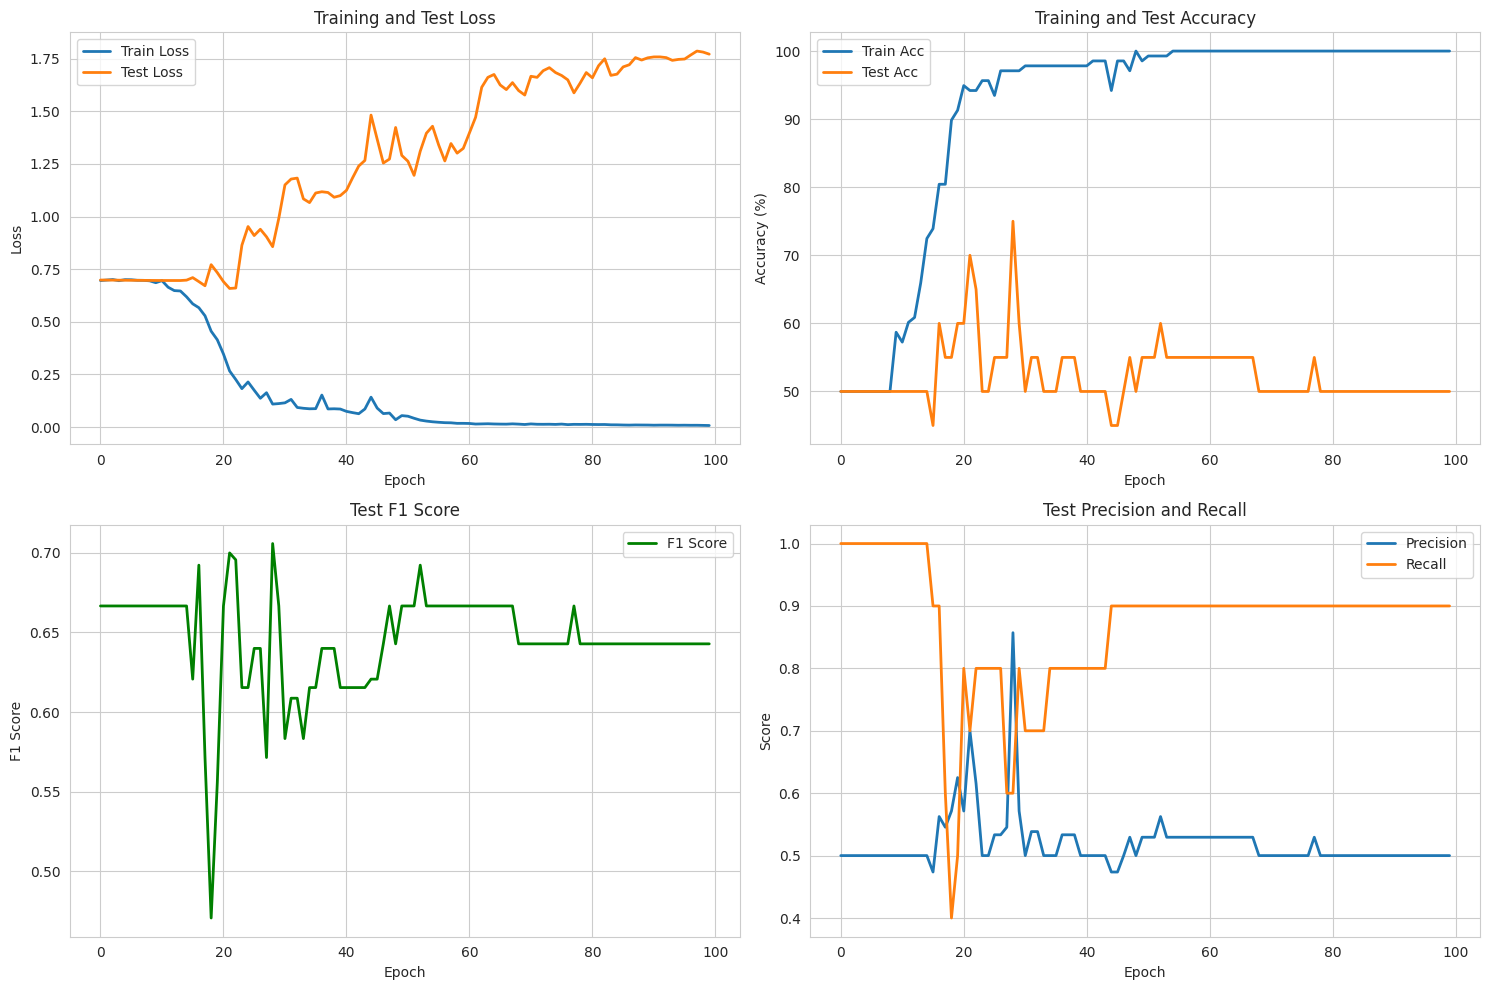

Training history plot saved to outputs/snn/training_history.png


In [8]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history['test_loss'], label='Test Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Test Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Accuracy
axes[0, 1].plot(history['train_acc'], label='Train Acc', linewidth=2)
axes[0, 1].plot(history['test_acc'], label='Test Acc', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Training and Test Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True)

# F1 Score
axes[1, 0].plot(history['test_f1'], label='F1 Score', linewidth=2, color='green')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].set_title('Test F1 Score')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Precision and Recall
axes[1, 1].plot(history['test_precision'], label='Precision', linewidth=2)
axes[1, 1].plot(history['test_recall'], label='Recall', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Test Precision and Recall')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('outputs/snn/training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("Training history plot saved to outputs/snn/training_history.png")

## 7. Final Evaluation

In [9]:
# Evaluate on test set
model.eval()
all_preds = []
all_targets = []
all_probs = []

inference_times = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        # Measure inference time
        start = time.time()
        outputs = model(inputs)
        inference_times.append(time.time() - start)
        
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())  # Probability of class 1

# Calculate metrics
accuracy = accuracy_score(all_targets, all_preds)
f1 = f1_score(all_targets, all_preds)
precision = precision_score(all_targets, all_preds)
recall = recall_score(all_targets, all_preds)
conf_matrix = confusion_matrix(all_targets, all_preds)

avg_inference_time = np.mean(inference_times) * 1000  # Convert to ms

print("=" * 60)
print("SNN FINAL EVALUATION METRICS")
print("=" * 60)
print(f"Accuracy:  {accuracy*100:.2f}%")
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"Avg Inference Time: {avg_inference_time:.2f} ms/batch")
print("=" * 60)

print("\nClassification Report:")
print(classification_report(all_targets, all_preds, target_names=['Down', 'Up']))

SNN FINAL EVALUATION METRICS
Accuracy:  50.00%
F1 Score:  0.6429
Precision: 0.5000
Recall:    0.9000
Avg Inference Time: 2.67 ms/batch

Classification Report:
              precision    recall  f1-score   support

        Down       0.50      0.10      0.17        10
          Up       0.50      0.90      0.64        10

    accuracy                           0.50        20
   macro avg       0.50      0.50      0.40        20
weighted avg       0.50      0.50      0.40        20



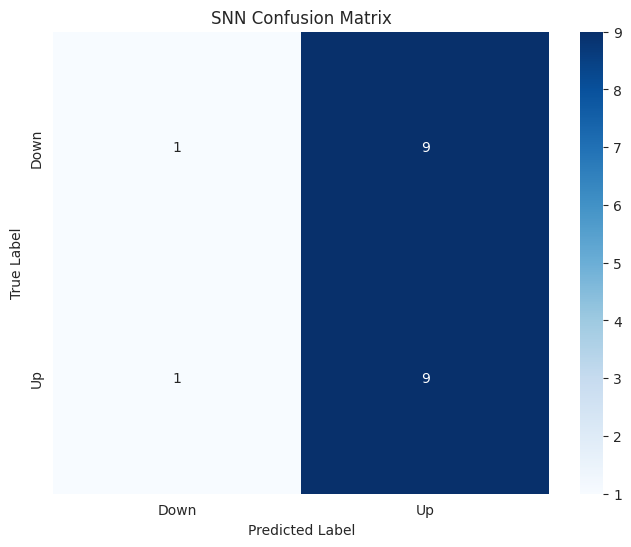

Confusion matrix saved to outputs/snn/confusion_matrix.png


In [10]:
# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.title('SNN Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('outputs/snn/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confusion matrix saved to outputs/snn/confusion_matrix.png")

## 8. Spike Train Visualization

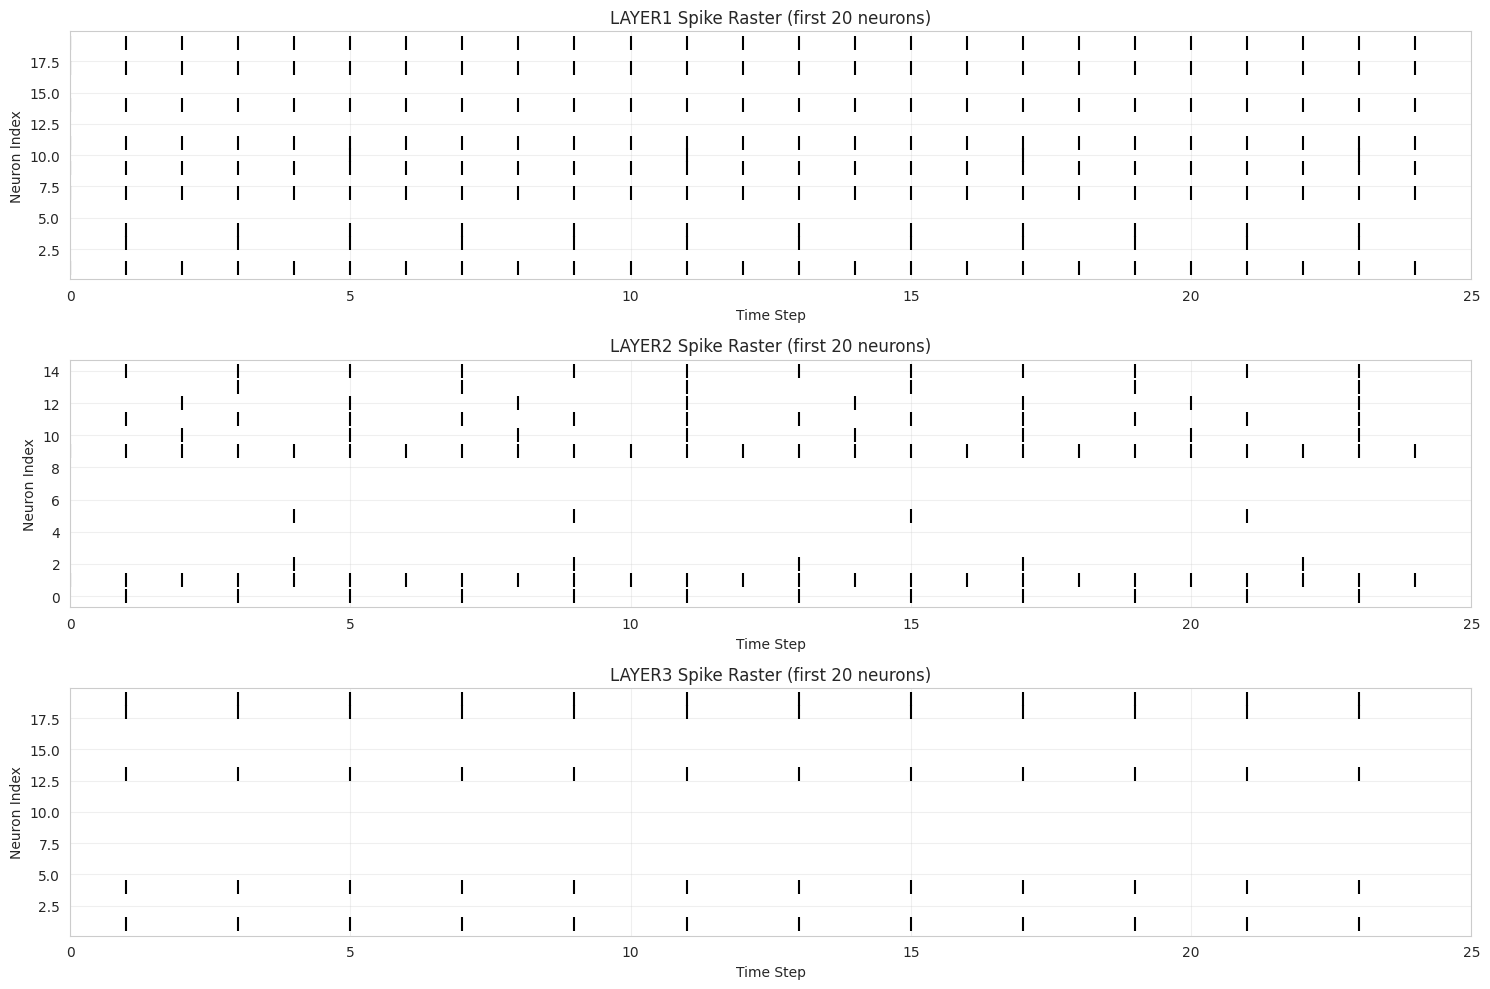

Spike raster plot saved to outputs/snn/spike_raster.png


In [11]:
# Visualize spike trains for a sample
model.eval()

# Get a batch
sample_batch, _ = next(iter(test_loader))
sample_input = sample_batch[:1].to(device)  # Take first sample

# Get spike counts
spike_counts = model.get_spike_counts(sample_input)

# Plot spike raster
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

layers = ['layer1', 'layer2', 'layer3']
for idx, layer_name in enumerate(layers):
    spikes = np.array(spike_counts[layer_name])  # (T, batch, neurons)
    spikes = spikes[:, 0, :20]  # First sample, first 20 neurons
    
    # Create raster plot
    for neuron in range(spikes.shape[1]):
        spike_times = np.where(spikes[:, neuron] > 0)[0]
        axes[idx].scatter(spike_times, [neuron] * len(spike_times), 
                         marker='|', s=100, c='black')
    
    axes[idx].set_ylabel('Neuron Index')
    axes[idx].set_xlabel('Time Step')
    axes[idx].set_title(f'{layer_name.upper()} Spike Raster (first 20 neurons)')
    axes[idx].set_xlim(0, model.T)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/snn/spike_raster.png', dpi=300, bbox_inches='tight')
plt.show()

print("Spike raster plot saved to outputs/snn/spike_raster.png")

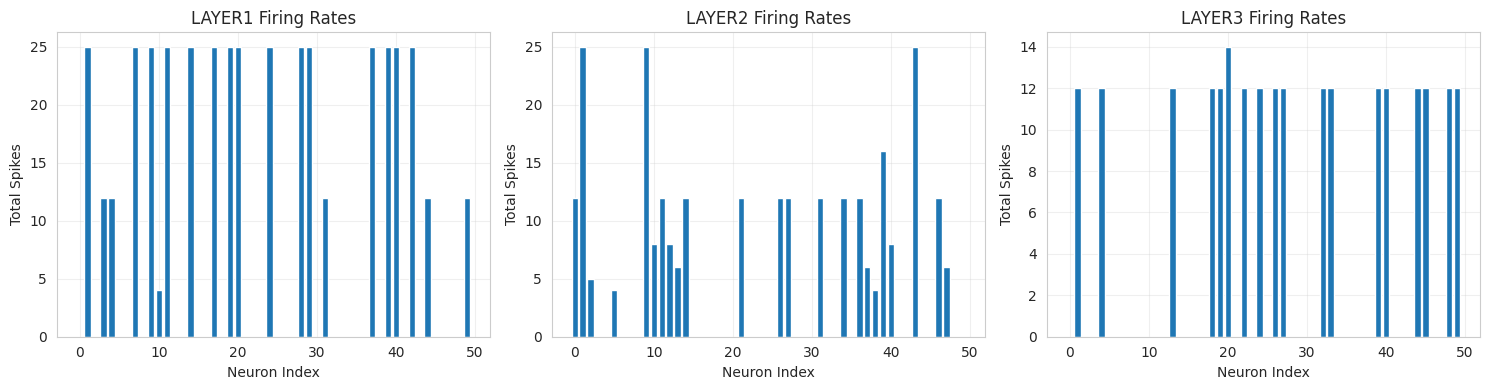

Firing rates plot saved to outputs/snn/firing_rates.png


In [12]:
# Visualize firing rates
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, layer_name in enumerate(layers):
    spikes = np.array(spike_counts[layer_name])  # (T, batch, neurons)
    firing_rates = spikes.sum(axis=0)[0, :]  # Sum over time, first sample
    
    axes[idx].bar(range(len(firing_rates[:50])), firing_rates[:50])
    axes[idx].set_xlabel('Neuron Index')
    axes[idx].set_ylabel('Total Spikes')
    axes[idx].set_title(f'{layer_name.upper()} Firing Rates')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/snn/firing_rates.png', dpi=300, bbox_inches='tight')
plt.show()

print("Firing rates plot saved to outputs/snn/firing_rates.png")

## 9. Backtesting Simulation

In [13]:
# Simple backtesting: long on up predictions, short on down predictions
test_df = data_dict['test_df'].iloc[20:]  # Skip first seq_len samples
test_df = test_df.reset_index()

# Add predictions
test_df['Predicted'] = all_preds[:len(test_df)]
test_df['Correct'] = (test_df['Predicted'] == test_df['Target']).astype(int)

# Calculate strategy returns
test_df['Returns'] = test_df['Close'].pct_change()
test_df['Strategy_Returns'] = test_df['Returns'] * (test_df['Predicted'] * 2 - 1)  # +1 for up, -1 for down

# Cumulative returns
test_df['Cumulative_Returns'] = (1 + test_df['Returns']).cumprod() - 1
test_df['Cumulative_Strategy_Returns'] = (1 + test_df['Strategy_Returns']).cumprod() - 1

# Calculate Sharpe ratio (assuming 252 trading days)
sharpe_ratio = test_df['Strategy_Returns'].mean() / test_df['Strategy_Returns'].std() * np.sqrt(252)

print("\n" + "=" * 60)
print("BACKTESTING RESULTS")
print("=" * 60)
print(f"Total Return (Buy & Hold): {test_df['Cumulative_Returns'].iloc[-1]*100:.2f}%")
print(f"Total Return (Strategy):   {test_df['Cumulative_Strategy_Returns'].iloc[-1]*100:.2f}%")
print(f"Sharpe Ratio:              {sharpe_ratio:.4f}")
print(f"Win Rate:                  {test_df['Correct'].mean()*100:.2f}%")
print("=" * 60)


BACKTESTING RESULTS
Total Return (Buy & Hold): -5.50%
Total Return (Strategy):   -7.94%
Sharpe Ratio:              -5.3646
Win Rate:                  50.00%


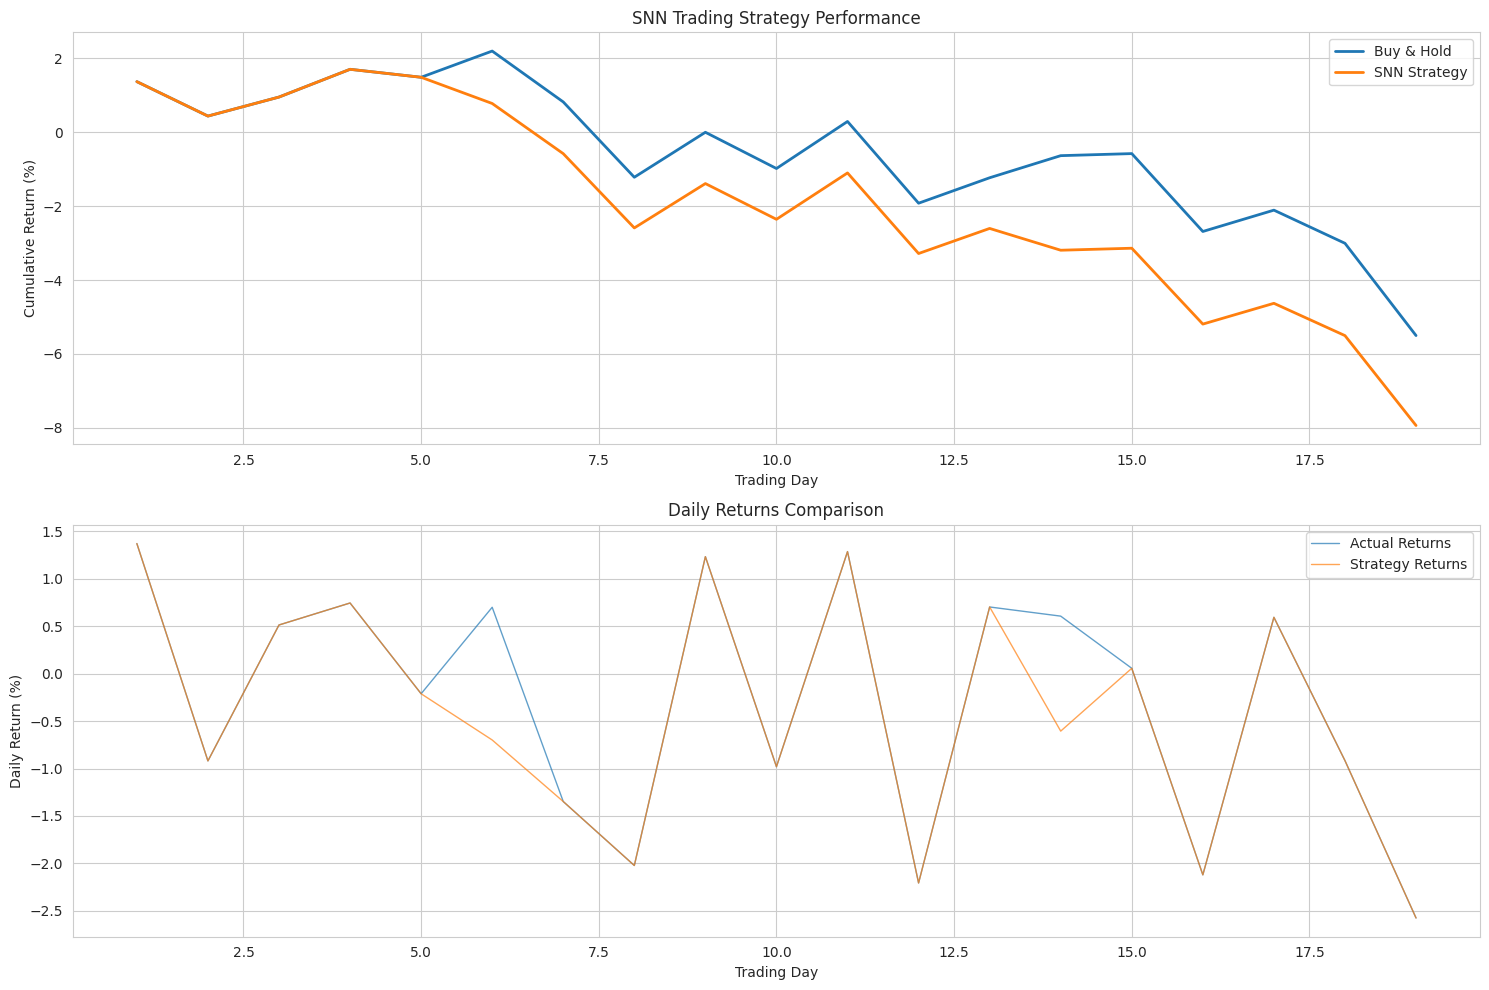

Backtest results plot saved to outputs/snn/backtest_results.png


In [14]:
# Plot backtest results
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Cumulative returns
axes[0].plot(test_df['Cumulative_Returns'] * 100, label='Buy & Hold', linewidth=2)
axes[0].plot(test_df['Cumulative_Strategy_Returns'] * 100, label='SNN Strategy', linewidth=2)
axes[0].set_xlabel('Trading Day')
axes[0].set_ylabel('Cumulative Return (%)')
axes[0].set_title('SNN Trading Strategy Performance')
axes[0].legend()
axes[0].grid(True)

# Daily returns
axes[1].plot(test_df['Returns'] * 100, label='Actual Returns', alpha=0.7, linewidth=1)
axes[1].plot(test_df['Strategy_Returns'] * 100, label='Strategy Returns', alpha=0.7, linewidth=1)
axes[1].set_xlabel('Trading Day')
axes[1].set_ylabel('Daily Return (%)')
axes[1].set_title('Daily Returns Comparison')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('outputs/snn/backtest_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("Backtest results plot saved to outputs/snn/backtest_results.png")

## 10. Save Results Summary

In [15]:
# Save all metrics to file
results_summary = {
    'model': 'SNN (SpikingJelly)',
    'architecture': {
        'hidden_size': 128,
        'num_layers': 3,
        'timesteps': model.T,
        'total_params': sum(p.numel() for p in model.parameters())
    },
    'training': {
        'epochs': num_epochs,
        'batch_size': batch_size,
        'learning_rate': 0.001,
        'training_time': training_time
    },
    'metrics': {
        'accuracy': float(accuracy),
        'f1_score': float(f1),
        'precision': float(precision),
        'recall': float(recall),
        'avg_inference_time_ms': float(avg_inference_time)
    },
    'backtesting': {
        'sharpe_ratio': float(sharpe_ratio),
        'total_return': float(test_df['Cumulative_Strategy_Returns'].iloc[-1]),
        'buy_hold_return': float(test_df['Cumulative_Returns'].iloc[-1]),
        'win_rate': float(test_df['Correct'].mean())
    }
}

# Save to pickle
with open('outputs/snn/results_summary.pkl', 'wb') as f:
    pickle.dump(results_summary, f)

# Save to text file
with open('outputs/snn/results_summary.txt', 'w') as f:
    f.write("SNN STOCK PREDICTION RESULTS SUMMARY\n")
    f.write("=" * 60 + "\n\n")
    
    f.write("ARCHITECTURE:\n")
    for key, value in results_summary['architecture'].items():
        f.write(f"  {key}: {value}\n")
    
    f.write("\nTRAINING:\n")
    for key, value in results_summary['training'].items():
        f.write(f"  {key}: {value}\n")
    
    f.write("\nMETRICS:\n")
    for key, value in results_summary['metrics'].items():
        f.write(f"  {key}: {value:.4f}\n")
    
    f.write("\nBACKTESTING:\n")
    for key, value in results_summary['backtesting'].items():
        f.write(f"  {key}: {value:.4f}\n")

print("Results summary saved to outputs/snn/results_summary.pkl and .txt")
print("\nSNN training and evaluation complete!")

Results summary saved to outputs/snn/results_summary.pkl and .txt

SNN training and evaluation complete!
